# Vegetation Phenology Analysis for Mission Planning

**Purpose:** Vegetation phenology -- the seasonal cycle of leaf-out, peak greenness, and senescence -- determines whether your science objectives can be met on a given flight day. Collecting data at the wrong phenological stage can compromise or invalidate an entire campaign: species composition mapping requires full canopy, carbon flux studies need peak greenness, and forest structure surveys may prefer leaf-off conditions. This notebook demonstrates how to use HyPlan's `phenology` module to analyze historical vegetation data and identify optimal collection windows that align with both science requirements and favorable weather.

| | |
|---|---|
| **Audience** | Intermediate |
| **Runtime** | < 1 minute (uses synthetic data; real data fetches take longer) |
| **Requires internet** | No (for this demo); Yes (for real EarthData fetches) |
| **Credentials required** | None (for this demo); Earthdata (for real MODIS data) |
| **Optional dependencies** | `pip install hyplan[phenology]`, `cartopy` (for maps) |
| **Uses example data** | Yes -- `exampledata/wdts.geojson` (Western US study areas) + synthetic NDVI |

**What You Will Learn:**
- Why vegetation phenology matters for mission timing and science quality
- How to retrieve and analyze NDVI/EVI phenology data from MODIS
- How to identify peak greenness timing and phenological stage transitions per site
- How to assess year-to-year phenology variability for robust scheduling
- How to combine cloud cover and phenology analysis to find optimal collection windows
- When to fly based on vegetation state (greenup, peak, senescence)

**Why phenology matters for mission planning:**
- **Species mapping** requires full canopy development -- flying during greenup misses late-leafing species
- **Carbon/productivity studies** need observations near peak greenness (maximum LAI/NDVI)
- **Forest structure** surveys using lidar may prefer leaf-off conditions for better ground penetration
- **Agriculture** monitoring depends on crop growth stage (planting, heading, senescence)
- **Phenology varies by 4-8 weeks** between sites at different elevations or latitudes, so a single campaign window rarely works for all sites

## Supported MODIS Products

| Product | Short Name | Resolution | Temporal | Variables |
|---------|-----------|-----------|----------|-----------|
| Vegetation Indices | MOD13A1 / MYD13A1 | 500 m | 16-day | NDVI, EVI |
| Leaf Area Index | MOD15A2H | 500 m | 8-day | LAI, FPAR |
| Phenology Transitions | MCD12Q2 | 500 m | Yearly | Greenup, peak, senescence dates |

## This Notebook

1. Study area definition
2. Fetching phenology data from EarthData (requires credentials)
3. Seasonal profile analysis (typical-year NDVI/EVI curves)
4. Phenological stage calendar (greenup to dormancy timeline)
5. Year-over-year variability heatmap
6. Combined cloud + phenology analysis for optimal collection windows

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from hyplan.phenology import (
    fetch_phenology,
    summarize_phenology_by_doy,
    extract_phenology_stages,
    plot_seasonal_profile,
    plot_phenology_calendar,
    plot_year_over_year_heatmap,
    plot_cloud_phenology_combined,
)

## 1. Study Area Definition

We use the same Western US study areas as the cloud analysis notebook. Each polygon represents a flight box that needs to be imaged. The five sites span a range of ecosystems: coastal chaparral, semi-arid scrubland, Mediterranean grassland, mixed conifer forest, and high-elevation conifer -- each with distinct phenological patterns.

Study areas: 5 polygons
         Name
santa_barbara
        socal
     yosemite
        tahoe
     bay_area


Text(0.5, 1.0, 'Study Area Polygons')

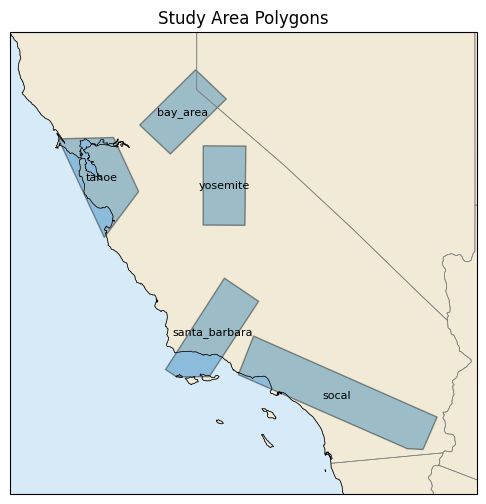

In [2]:
polygon_file = "exampledata/wdts.geojson"

gdf = gpd.read_file(polygon_file)
print(f"Study areas: {len(gdf)} polygons")
print(gdf[["Name"]].to_string(index=False))

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-124, -114, 32, 40], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f0ead6")
ax.add_feature(cfeature.OCEAN, facecolor="#d6eaf8")
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.5)

gdf.plot(ax=ax, alpha=0.4, edgecolor="black", transform=ccrs.PlateCarree())

for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["Name"], fontsize=8,
            ha="center", va="center", transform=ccrs.PlateCarree())

ax.set_title("Study Area Polygons")

## 2. Fetching Phenology Data from EarthData

**How it works:** `fetch_phenology` searches NASA's Common Metadata Repository (CMR) for MODIS granules covering your study areas, downloads them to a local cache, and extracts QA-filtered vegetation index values per polygon.

**Prerequisites:**
- `pip install hyplan[phenology]`
- NASA Earthdata account ([register here](https://urs.earthdata.nasa.gov))
- Set `EARTHDATA_TOKEN` environment variable, or configure `~/.netrc`

The call below shows the API for fetching 20 years of NDVI data. Since it requires EarthData credentials and downloads several GB of MODIS granules, the rest of this notebook uses synthetic data that mimics realistic phenology patterns for the Western US sites.

In [3]:
# --- Uncomment to fetch real data (requires EarthData credentials) ---
#
# ndvi_df = fetch_phenology(
#     polygon_file=polygon_file,
#     product="ndvi",
#     year_start=2003,
#     year_stop=2022,
#     satellite="terra",        # "terra", "aqua", or "combined"
#     spatial_mode="mean",      # "mean" or "pixel_stats"
# )
#
# # Phenology transitions (greenup, peak, senescence dates)
# pheno_df = fetch_phenology(
#     polygon_file=polygon_file,
#     product="phenology",
#     year_start=2003,
#     year_stop=2022,
# )

print("fetch_phenology() parameters:")
print("  product:      'ndvi', 'evi', 'lai', 'fpar', 'phenology'")
print("  satellite:    'terra', 'aqua', 'combined' (ndvi/evi only)")
print("  spatial_mode: 'mean' or 'pixel_stats'")
print("  year_start:   default 2003")
print("  year_stop:    default 2022")

fetch_phenology() parameters:
  product:      'ndvi', 'evi', 'lai', 'fpar', 'phenology'
  satellite:    'terra', 'aqua', 'combined' (ndvi/evi only)
  spatial_mode: 'mean' or 'pixel_stats'
  year_start:   default 2003
  year_stop:    default 2022


### Synthetic Data for Demonstration

The synthetic data below mimics realistic NDVI phenology patterns for
five Western US sites with different vegetation types:

- **santa_barbara** — Coastal chaparral, moderate year-round greenness
- **socal** — Semi-arid scrub, spring green-up after winter rains
- **yosemite** — Mixed conifer forest, strong summer peak
- **tahoe** — High-elevation conifer, snow-limited short growing season
- **bay_area** — Mediterranean grassland, winter-green / summer-brown

In [4]:
import datetime as dt

np.random.seed(42)

# Site-specific phenology parameters: (base, amplitude, phase_doy, noise_std)
# NDVI ≈ base + amplitude * sin(2π(doy - phase) / 365)
site_params = {
    "santa_barbara": (0.35, 0.15, 90, 0.03),   # mild seasonal cycle
    "socal":         (0.20, 0.15, 75, 0.04),    # spring peak, dry summer
    "yosemite":      (0.30, 0.35, 180, 0.04),   # strong summer peak
    "tahoe":         (0.25, 0.30, 190, 0.05),   # late summer peak, snow winter
    "bay_area":      (0.35, 0.20, 60, 0.03),    # winter-green, peaks early spring
}

years = range(2003, 2023)
doys = range(1, 366, 16)  # 16-day MODIS composites

rows = []
for year in years:
    for doy in doys:
        for site, (base, amp, phase, noise) in site_params.items():
            # Add interannual variability (±10% of amplitude)
            year_offset = np.random.uniform(-0.1, 0.1) * amp
            value = base + (amp + year_offset) * np.sin(
                2 * np.pi * (doy - phase) / 365
            )
            value += np.random.normal(0, noise)
            value = np.clip(value, 0.0, 1.0)

            rows.append({
                "polygon_id": site,
                "date": dt.datetime(year, 1, 1) + dt.timedelta(days=doy - 1),
                "year": year,
                "day_of_year": doy,
                "value": round(value, 4),
            })

ndvi_df = pd.DataFrame(rows)
print(f"Synthetic NDVI data: {len(ndvi_df)} rows")
print(f"Polygons: {sorted(ndvi_df['polygon_id'].unique())}")
print(f"Years: {ndvi_df['year'].min()}–{ndvi_df['year'].max()}")
print(f"NDVI range: {ndvi_df['value'].min():.2f} – {ndvi_df['value'].max():.2f}")
ndvi_df.head(10)

Synthetic NDVI data: 2300 rows
Polygons: ['bay_area', 'santa_barbara', 'socal', 'tahoe', 'yosemite']
Years: 2003–2022
NDVI range: 0.00 – 0.74


,polygon_id,date,year,day_of_year,value
0,santa_barbara,2003-01-01,2003,1,0.1705
1,socal,2003-01-01,2003,1,0.0792
2,yosemite,2003-01-01,2003,1,0.2919
3,tahoe,2003-01-01,2003,1,0.3354
4,bay_area,2003-01-01,2003,1,0.1789
5,santa_barbara,2003-01-17,2003,17,0.2006
6,socal,2003-01-17,2003,17,0.0000
7,yosemite,2003-01-17,2003,17,0.2275
8,tahoe,2003-01-17,2003,17,0.1787
9,bay_area,2003-01-17,2003,17,0.1964


## 3. Seasonal Profile Analysis

**The question:** What does the "typical year" look like for vegetation at each site? `summarize_phenology_by_doy` averages NDVI across all years for each day-of-year, producing a seasonal curve per site. This reveals when greenup begins, when peak greenness occurs, and when senescence starts -- the key information for scheduling a campaign around vegetation state.

The optional `window` parameter applies centered rolling-mean smoothing to reduce noise from individual compositing periods.

In [5]:
# Compute DOY summary with 3-point smoothing
ndvi_summary = summarize_phenology_by_doy(ndvi_df, window=3)

print(f"Summary: {len(ndvi_summary)} rows")
print(f"Columns: {list(ndvi_summary.columns)}")
ndvi_summary.head(10)

Summary: 115 rows
Columns: ['polygon_id', 'day_of_year', 'value_mean', 'value_std', 'value_count']


,polygon_id,day_of_year,value_mean,value_std,value_count
0,bay_area,1,0.195962,0.031476,20
1,bay_area,17,0.215208,0.035632,20
2,bay_area,33,0.256647,0.026869,20
3,bay_area,49,0.307002,0.025698,20
4,bay_area,65,0.359693,0.034540,20
5,bay_area,81,0.416617,0.027258,20
6,bay_area,97,0.463885,0.025665,20
7,bay_area,113,0.504877,0.022546,20
8,bay_area,129,0.528170,0.036529,20
9,bay_area,145,0.542637,0.034252,20


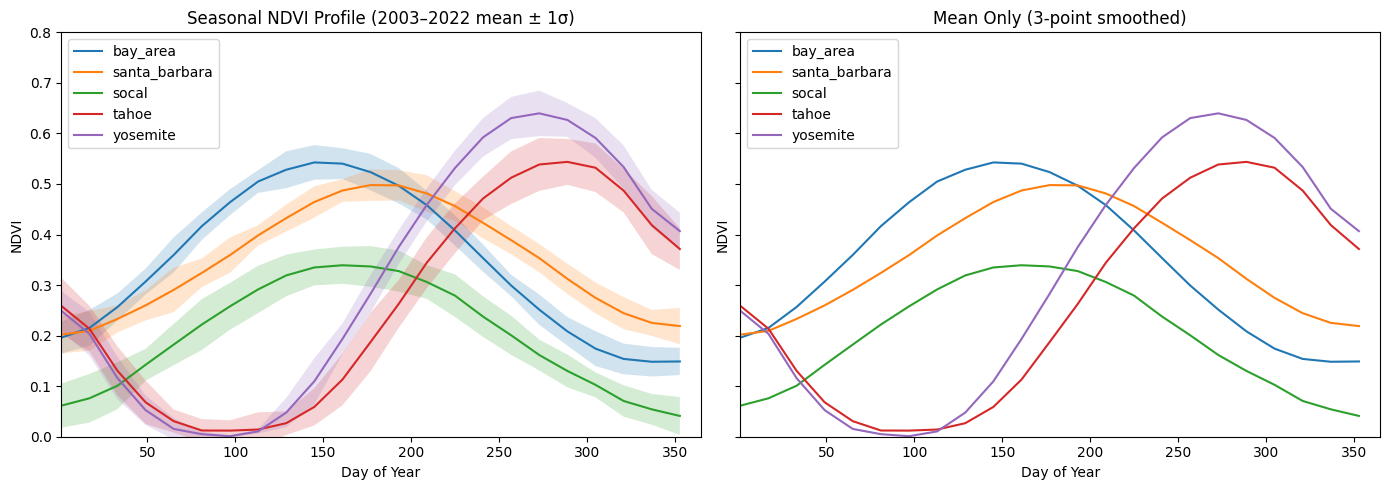


Peak NDVI timing per site:
  bay_area          DOY 145  NDVI = 0.54
  santa_barbara     DOY 177  NDVI = 0.50
  socal             DOY 161  NDVI = 0.34
  tahoe             DOY 289  NDVI = 0.54
  yosemite          DOY 273  NDVI = 0.64


In [6]:
# Plot seasonal NDVI profiles for all sites
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_seasonal_profile(ndvi_summary, ax=axes[0], ylabel="NDVI")
axes[0].set_title("Seasonal NDVI Profile (2003–2022 mean ± 1σ)")
axes[0].set_ylim(0, 0.8)

# Without std bands for a cleaner comparison
plot_seasonal_profile(ndvi_summary, ax=axes[1], show_std=False, ylabel="NDVI")
axes[1].set_title("Mean Only (3-point smoothed)")
axes[1].set_ylim(0, 0.8)

fig.tight_layout()
plt.show()

# Identify peak greenness timing per site
print("\nPeak NDVI timing per site:")
for site in sorted(ndvi_summary["polygon_id"].unique()):
    sub = ndvi_summary[ndvi_summary["polygon_id"] == site].sort_values(
        "value_mean", ascending=False
    )
    peak = sub.iloc[0]
    print(f"  {site:16s}  DOY {peak['day_of_year']:3.0f}  NDVI = {peak['value_mean']:.2f}")

**Interpreting the profiles:** The seasonal curves reveal dramatically different phenology patterns across the five sites:

- **Bay Area** peaks early (DOY ~145, late May) -- Mediterranean grasslands green up with winter rains and dry out by summer
- **Santa Barbara and SoCal** peak in early-to-mid summer, reflecting chaparral and scrub phenology
- **Yosemite and Tahoe** peak in late summer/early fall (DOY ~270-290), constrained by snowmelt timing at high elevations

**Operational implication:** A single campaign window cannot capture peak greenness at all five sites. If your science requires peak-greenness observations, you need either multiple deployment windows or a long enough campaign to span the 4-5 month range between the earliest and latest peaks.

## 4. Phenological Stage Calendar

**Why stages matter:** Rather than just "peak greenness," many science objectives require specific phenological stages. For example, detecting early-season invasive species requires observations during greenup (before native species leaf out), while fall color mapping requires observations during senescence.

The MCD12Q2 product provides transition dates (greenup, peak, senescence, dormancy) for each year. `extract_phenology_stages` computes the multi-year mean and standard deviation of each transition, and `plot_phenology_calendar` renders a Gantt-style chart showing when each site is in each phenological stage. This makes it easy to pick campaign windows that target a specific vegetation state.

In [7]:
# Synthetic MCD12Q2-style phenology transition data
# In practice, this comes from fetch_phenology(product="phenology")

np.random.seed(123)

# Realistic transition DOYs for Western US sites
transition_params = {
    #                   greenup  midgrnup  peak  maturity  midgrndn  senescence  dormancy
    "bay_area":       (  45,       70,     100,    130,      200,       240,       290),
    "santa_barbara":  (  60,       85,     120,    150,      220,       260,       310),
    "socal":          (  50,       75,     105,    135,      195,       235,       285),
    "yosemite":       ( 100,      130,     170,    200,      250,       280,       320),
    "tahoe":          ( 120,      150,     190,    220,      260,       290,       330),
}

pheno_rows = []
for year in range(2003, 2023):
    for site, doys in transition_params.items():
        row = {"polygon_id": site, "year": year}
        stage_names = [
            "greenup_doy", "midgreenup_doy", "peak_doy", "maturity_doy",
            "midgreendown_doy", "senescence_doy", "dormancy_doy",
        ]
        for name, base_doy in zip(stage_names, doys):
            # Add interannual variability (±7 days)
            row[name] = base_doy + np.random.normal(0, 4)
        pheno_rows.append(row)

pheno_df = pd.DataFrame(pheno_rows)
print(f"Phenology transitions: {len(pheno_df)} rows, {len(pheno_df['polygon_id'].unique())} sites")
pheno_df.head()

Phenology transitions: 100 rows, 5 sites


,polygon_id,year,greenup_doy,midgreenup_doy,peak_doy,maturity_doy,midgreendown_doy,senescence_doy,dormancy_doy
0,bay_area,2003,40.657478,73.989382,101.131914,123.974821,197.685599,246.605746,280.293283
1,santa_barbara,2003,58.284349,90.063745,116.533038,147.284455,219.621164,265.965559,307.444392
2,socal,2003,48.224072,73.262595,113.823720,143.747144,199.016216,236.544746,287.949474
3,yosemite,2003,105.962928,126.256665,174.703316,194.984477,247.448994,283.628421,314.285277
4,tahoe,2003,119.439725,146.552980,188.977523,208.805644,252.913868,287.200491,333.709850


In [8]:
# Compute multi-year mean/std of transition dates
stages = extract_phenology_stages(pheno_df)

print("Mean phenological transition DOYs:\n")
print(stages[["polygon_id", "greenup_doy_mean", "peak_doy_mean",
              "senescence_doy_mean", "dormancy_doy_mean"]].to_string(index=False))

Mean phenological transition DOYs:

   polygon_id  greenup_doy_mean  peak_doy_mean  senescence_doy_mean  dormancy_doy_mean
     bay_area         44.252074      98.367269           241.073442         289.198220
santa_barbara         60.745536     120.381162           260.565027         310.816320
        socal         51.112864     105.932858           236.021414         284.847494
        tahoe        120.066129     190.147713           290.506917         330.720172
     yosemite         98.641709     170.919165           279.748571         319.540617


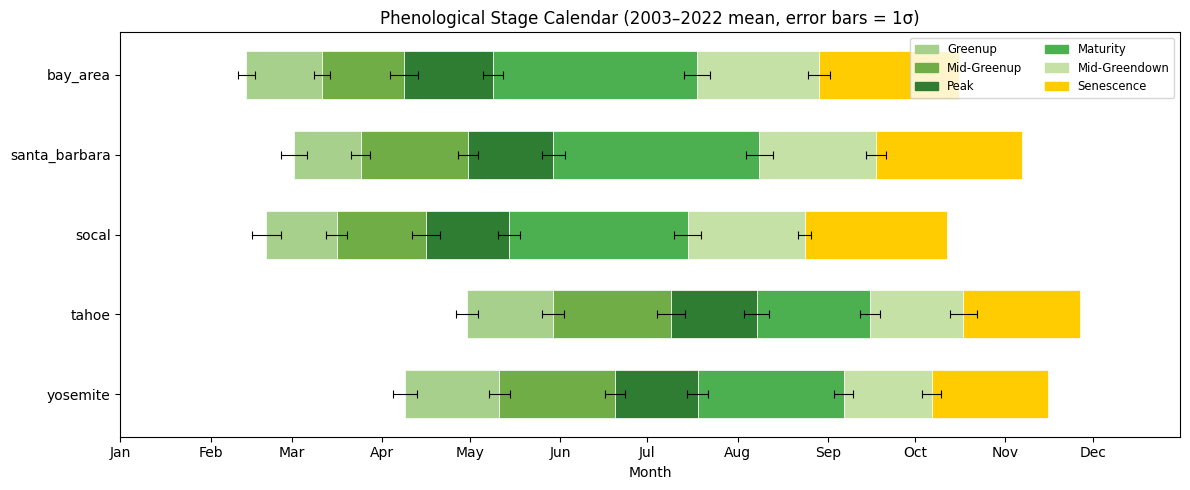

In [9]:
# Gantt chart of phenological stages
ax = plot_phenology_calendar(stages)
ax.set_title("Phenological Stage Calendar (2003–2022 mean, error bars = 1σ)")
plt.tight_layout()
plt.show()

**Interpreting the calendar:** The Gantt chart shows that all five sites are simultaneously at "peak" phenological stage only during a narrow window around DOY 190-220 (July). Before that, low-elevation sites are already past peak while high-elevation sites are still greening up. After that, low-elevation sites enter senescence while high-elevation sites remain green. The error bars (1 standard deviation) show that transition timing varies by about 1-2 weeks between years, so plan with some buffer.

**Operational implication:** If your science requires all sites at peak greenness, target July. If you need greenup observations (for invasive species detection or spring phenology studies), plan for March-April at low elevations or May-June at high elevations.

## 5. Year-over-Year Variability

**Why variability matters:** Average phenology tells you *when* to plan, but variability tells you *how much buffer* to build in. A site with highly consistent phenology timing can be targeted with a narrow campaign window, while a variable site needs a wider window or contingency plans.

The year-over-year heatmap reveals interannual variability in phenology timing. Each row is a year, each column is a day-of-year, and the color represents NDVI. Look for:
- **Consistent timing** -- vertical color bands stay in the same position across years
- **Early/late years** -- bands shift left or right
- **Drought years** -- overall dimmer colors (lower peak NDVI)

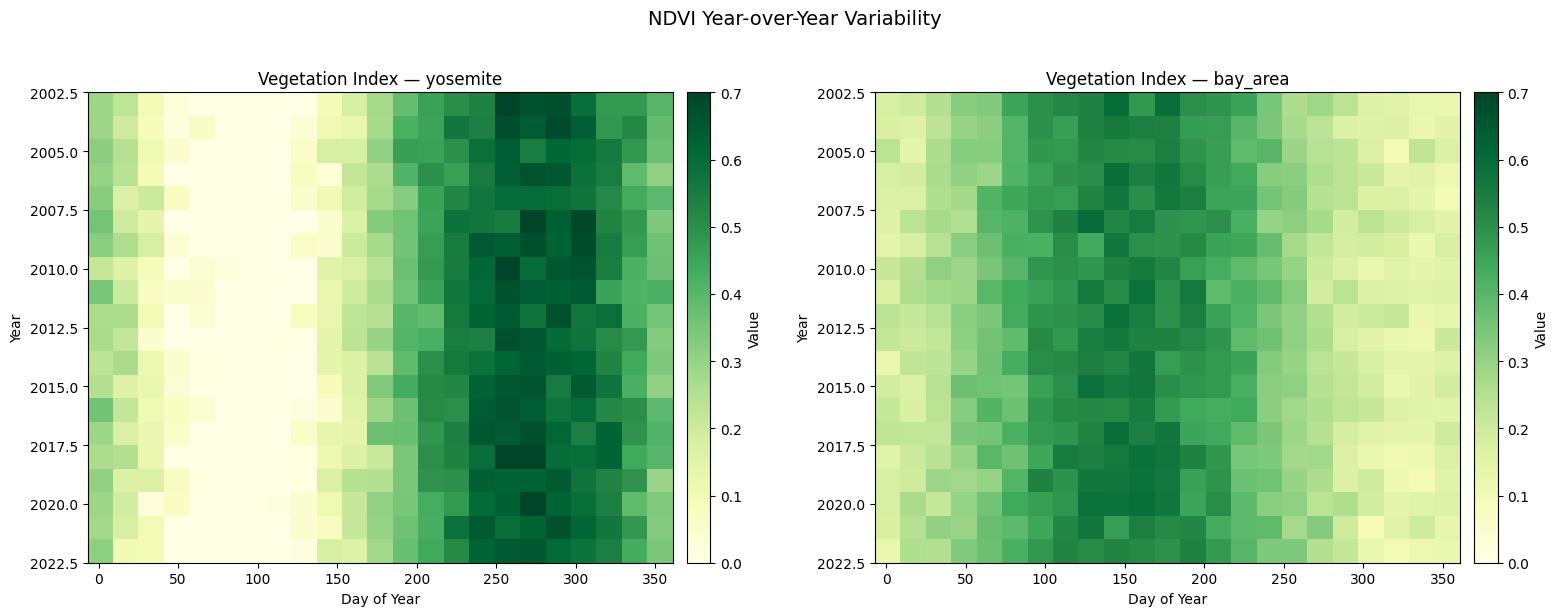

In [10]:
# Heatmaps for two contrasting sites
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_year_over_year_heatmap(
    ndvi_df, polygon_id="yosemite", ax=axes[0],
    cmap="YlGn", vmin=0.0, vmax=0.7,
)

plot_year_over_year_heatmap(
    ndvi_df, polygon_id="bay_area", ax=axes[1],
    cmap="YlGn", vmin=0.0, vmax=0.7,
)

fig.suptitle("NDVI Year-over-Year Variability", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

**Interpreting the heatmaps:** Compare the two sites: Yosemite (conifer forest) shows consistent phenology timing with the green band appearing at nearly the same DOY each year, indicating reliable scheduling. Bay Area (grassland) shows more year-to-year variability, with greenup timing shifting by several weeks depending on winter rainfall. For mission planning, Yosemite can be confidently scheduled to a specific 2-week window, while Bay Area requires a wider deployment window or real-time monitoring of vegetation state before flying.

## 6. Combined Cloud + Phenology Analysis

**The key insight:** The most powerful planning tool is the intersection of cloud cover and phenology. A site may have perfect vegetation conditions but persistent clouds, or clear skies but dormant vegetation. Only time windows where *both* conditions are met -- low cloud cover AND desired vegetation state -- are viable for data collection.

`plot_cloud_phenology_combined` overlays both datasets to identify these windows. Two layout modes are available:
- `"overlay"` -- twin y-axes on a single plot (cloud fraction on left, NDVI on right)
- `"side_by_side"` -- two stacked panels with a shared x-axis

In [11]:
# Generate synthetic cloud fraction summary (matching clouds module output)
# In practice: cloud_summary = summarize_cloud_fraction_by_doy(cloud_df)

np.random.seed(99)
cloud_rows = []
for doy in range(1, 366, 1):
    for site, params in site_params.items():
        # Cloud fraction: higher in winter, lower in summer (California pattern)
        cf = 0.55 - 0.30 * np.sin(2 * np.pi * (doy - 30) / 365)
        cf += np.random.normal(0, 0.02)
        cf = np.clip(cf, 0, 1)
        cloud_rows.append({
            "polygon_id": site,
            "day_of_year": doy,
            "cloud_fraction_mean": round(cf, 3),
            "cloud_fraction_std": round(abs(np.random.normal(0.10, 0.02)), 3),
        })

cloud_summary = pd.DataFrame(cloud_rows)
print(f"Cloud summary: {len(cloud_summary)} rows")

Cloud summary: 1825 rows


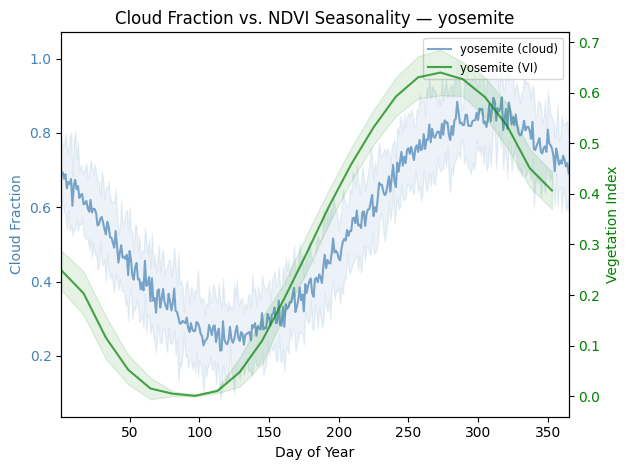

In [12]:
# Overlay mode: cloud fraction (blue, left axis) + NDVI (green, right axis)
# Filter to one site for clarity
site = "yosemite"
cloud_one = cloud_summary[cloud_summary["polygon_id"] == site]
ndvi_one = ndvi_summary[ndvi_summary["polygon_id"] == site]

ax = plot_cloud_phenology_combined(
    cloud_one, ndvi_one, layout="overlay",
)
ax.set_title(f"Cloud Fraction vs. NDVI Seasonality — {site}")
plt.tight_layout()
plt.show()

**Interpreting the overlay:** For Yosemite, NDVI peaks around DOY 270 but cloud fraction is also high (~80%) at that time. The best compromise window is earlier in summer (DOY 180-220) when NDVI is near peak and cloud fraction is lower. This kind of trade-off analysis is the core value of combining phenology and cloud data -- the "perfect" phenological window may not be the "best" operational window.

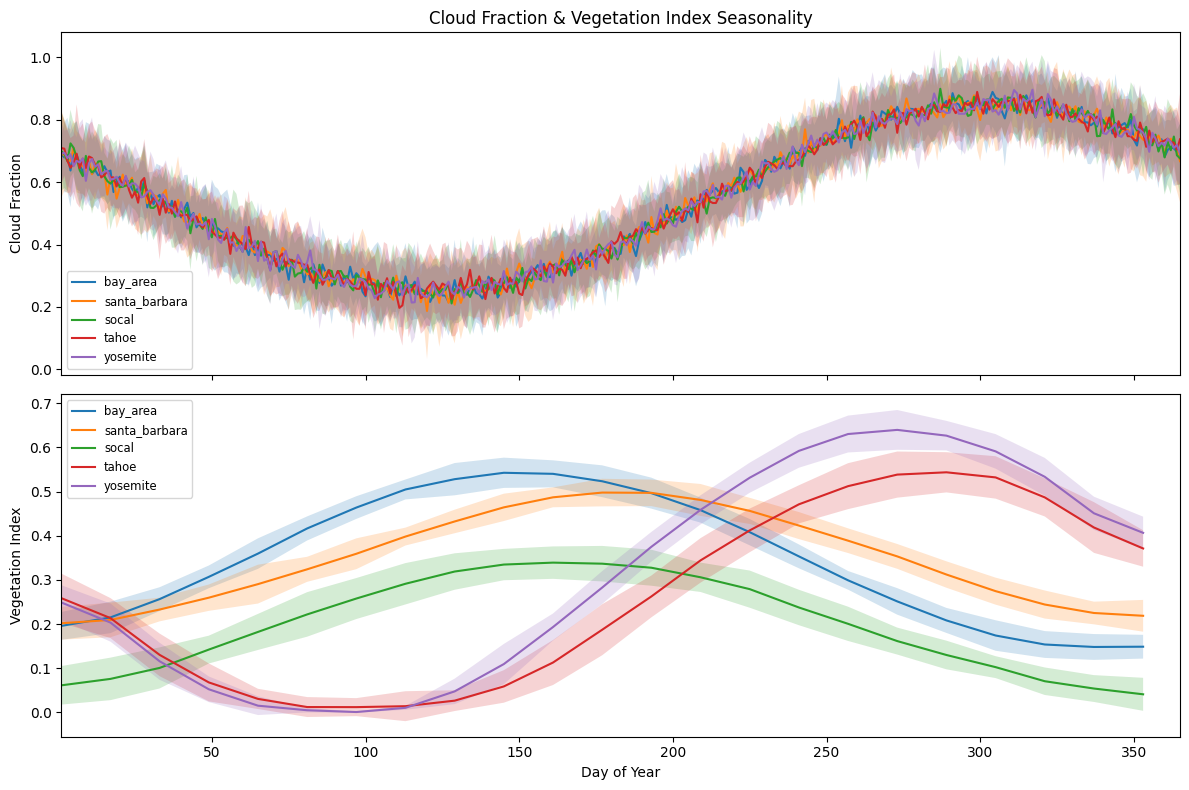

In [13]:
# Side-by-side mode: all sites, two stacked panels
fig = plot_cloud_phenology_combined(
    cloud_summary, ndvi_summary, layout="side_by_side",
)
plt.show()

## 7. Planning Recommendations

**Bringing it all together:** The table below combines peak NDVI timing with cloud fraction at that time to identify the optimal collection window for each site. The "window" spans +/- 16 days around peak NDVI, giving a one-month target for campaign scheduling.

In [14]:
# Find optimal windows: peak NDVI with low cloud fraction
print("Optimal collection windows (peak greenness + clear skies):\n")
print(f"{'Site':16s}  {'Peak NDVI DOY':>14s}  {'Cloud Frac':>11s}  {'Window':>20s}")
print("-" * 67)

for site in sorted(ndvi_summary["polygon_id"].unique()):
    # Find DOY of peak NDVI
    ndvi_sub = ndvi_summary[ndvi_summary["polygon_id"] == site].sort_values(
        "value_mean", ascending=False,
    )
    peak_doy = int(ndvi_sub.iloc[0]["day_of_year"])

    # Get cloud fraction around peak
    cloud_sub = cloud_summary[cloud_summary["polygon_id"] == site]
    cloud_at_peak = cloud_sub[
        (cloud_sub["day_of_year"] >= peak_doy - 16)
        & (cloud_sub["day_of_year"] <= peak_doy + 16)
    ]["cloud_fraction_mean"].mean()

    # Convert DOY to approximate date
    approx_date = dt.datetime(2020, 1, 1) + dt.timedelta(days=peak_doy - 1)
    window_start = approx_date - dt.timedelta(days=16)
    window_end = approx_date + dt.timedelta(days=16)

    print(
        f"{site:16s}  {peak_doy:14d}  {cloud_at_peak:11.0%}  "
        f"{window_start.strftime('%b %d')} – {window_end.strftime('%b %d')}"
    )

Optimal collection windows (peak greenness + clear skies):

Site               Peak NDVI DOY   Cloud Frac                Window
-------------------------------------------------------------------
bay_area                     145          28%  May 08 – Jun 09
santa_barbara                177          38%  Jun 09 – Jul 11
socal                        161          32%  May 24 – Jun 25
tahoe                        289          83%  Sep 29 – Oct 31
yosemite                     273          80%  Sep 13 – Oct 15


**Interpreting the recommendations:** The table reveals a fundamental tension: sites with the latest peak greenness (Tahoe, Yosemite) also have the highest cloud fractions at peak time (80-83%). This means high-elevation sites may require accepting sub-peak vegetation conditions in exchange for better flying weather. For Bay Area and SoCal, the situation is more favorable -- peak greenness coincides with moderate cloud cover (28-32%), making these sites easier to schedule.

**When to fly based on vegetation state:**
- **Full canopy / species mapping:** Target the "peak" to "maturity" window (see phenology calendar)
- **Carbon flux / productivity:** Fly within 2 weeks of peak NDVI
- **Forest structure (lidar):** Fly during dormancy for deciduous sites; timing is less critical for evergreen conifers
- **Invasive species:** Fly during greenup when phenological differences between native and invasive species are most pronounced

## Operational Takeaways

- **Phenology is a hard constraint for many science objectives.** Unlike weather, which is stochastic and can be waited out, phenology follows a deterministic seasonal progression. Missing the target phenological stage means waiting until next year.
- **Peak greenness timing varies by 4-5 months** across sites at different elevations and latitudes. A multi-site campaign must either accept non-peak conditions at some sites or schedule multiple deployment windows.
- **Year-to-year variability is site-dependent.** High-elevation conifer sites have consistent timing (+/- 1 week), while rainfall-dependent grasslands can shift by 3-4 weeks. Budget wider deployment windows for variable sites.
- **Combine phenology with cloud analysis** to find realistic collection windows. The "perfect" phenological window may have 80% cloud cover; the "best" operational window balances vegetation state and flying weather.
- **Use near-real-time NDVI** (from MODIS or Sentinel-2) to monitor vegetation state during the campaign. Do not rely solely on historical averages -- the current year may be early or late.
- **Consider using phenology stages** (greenup, peak, senescence) rather than calendar dates for scheduling triggers. This makes plans robust to interannual variability.

## API Summary

| Function | Purpose |
|----------|---------|
| `fetch_phenology()` | Retrieve NDVI/EVI/LAI/FPAR or phenology transitions from MODIS via EarthData |
| `fetch_phenology_spatial()` | Per-pixel time-averaged vegetation maps |
| `summarize_phenology_by_doy()` | Compute typical-year seasonal profile |
| `extract_phenology_stages()` | Multi-year mean/std of transition dates |
| `plot_seasonal_profile()` | Line plot of VI seasonality |
| `plot_phenology_calendar()` | Gantt chart of phenological stages |
| `plot_year_over_year_heatmap()` | DOY x year heatmap |
| `plot_cloud_phenology_combined()` | Overlay or side-by-side cloud + phenology |

**Installation:** `pip install hyplan[phenology]`

**Credentials:** NASA Earthdata account required -- set `EARTHDATA_TOKEN`
or configure `~/.netrc`. Register at https://urs.earthdata.nasa.gov